In [4]:
import time, logging, importlib
import helpers; importlib.reload(helpers)

# 1. Cache check: second serial_ports() call should be ~instant
t0 = time.perf_counter(); helpers.serial_ports(); t1 = time.perf_counter()
helpers.serial_ports(); t2 = time.perf_counter()
print(f"serial_ports first: {t1-t0:.3f}s, cached: {t2-t1:.5f}s")

# 2. INFO-level discovery: should print exactly one "[helpers] Found device at: ..."
helpers.findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)

# 3. Bump to DEBUG and re-run: now you should see "[helpers] Received message: ..." per port
logging.getLogger("helpers").setLevel(logging.DEBUG)
helpers.findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)

# 4. Reset to INFO
logging.getLogger("helpers").setLevel(logging.INFO)


serial_ports first: 0.052s, cached: 0.00008s
[helpers] No matching device found
[helpers] Received message: MultispeQ Ready
MultispeQ Ready, port: COM3
[helpers] Received message: NEW Name Here Ready, port: COM4
[helpers] Found device at: COM4, answer: NEW Name Here Ready



In [1]:
import sys
import time
import serial
import glob
from matplotlib import pyplot as plt
import numpy as np
from helpers import (
    findDevice, set_voltage, set_current, get_par_MP, get_par_AMB,
    r_squared, plot_data_and_fit, set_par_gain, set_ambit_led_gain,
    set_ambit_led, ambit_reboot, AmbitInfo
)


In [2]:
# Initialize ports for Ambit
PORT_AMBIT = findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)
if(PORT_AMBIT is None):
    PORT_AMBIT = findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)



[helpers] No matching device found
[helpers] Found device at: COM4, answer: NEW Name Here Ready



In [ ]:

info = ambit_reboot(PORT_AMBIT)

print(info)

metadata = {
    "name": info.name,
    "firmware_version": info.FW,
    "isValid": info.IsValid,
    "old_actinic_gain": info.act_led_coeff,
    "old_light_slope": info.light_slope,
}

# print(metadata)


b'ESP-ROM:esp32c3-api1-20210207\r\n'
b'Build:Feb  7 2021\r\n'
b'rst:0xc (RTC_SW_CPU_RST),boot:0xd (SPI_FAST_FLASH_BOOT)\r\n'
b'Saved PC:0x403819c4\r\n'
b'SPIWP:0xee\r\n'
b'mode:DIO, clock div:1\r\n'
b'load:0x3fcd5820,len:0x1144\r\n'
b'load:0x403cc710,len:0xad8\r\n'
b'load:0x403ce710,len:0x2f80\r\n'
b'entry 0x403cc710\r\n'
b'BOOT\r\n'
b'259224\r\n'
b'ADPD Found, chip version: 2\n'
b'Metadata: lon:0.000000\tlat:0.000000\talt:0.000000\ttime:0\tacc:0.000000\tvacc:0.000000\tinfo1:8C\tx:0.000000\ty:0.000000\tz:0.000000\n'
b'Calibration: Name:AmbitV004\tActinic:0.049213\tSpec:0.186300\tEmit:1.000000\tSun:1.000000\tTemp_offset:0.000000\tTemp_slope:1.000000\n'
b'Calibration: Act_50:983\tAct_100:2032\tAct_150:3121\tAct_200:4174\tAct_250:5233\n'
b'Calibration: ADPD: 0\t0\t0\t0\t0\t0\n'
b'MLX: 5829844\t78530480\t0\t6400\t4908155\t5829844\t67377408\t-53767196\t-39611924\t16384\t0\t10752\t10752\t69140899\t\n'
b'FW: MAC:38514fa89110\tSize:539216\tDate:Jul 30 2025\n'
b'FW: 0.0.4\n'
FW: b'0.0.4', light

In [2]:
# Initialize ports for MiniPAR
#PORT_MINIPAR = findDevice(question="hello\n",answer="MiniPAR",flush=True,timeout=2)
PORT_MINIPAR_PAR = findDevice(question="get_name\n",answer="Par_REF",flush=True,timeout=2)
PORT_MINIPAR_EMIT = findDevice(question="get_name\n",answer="Emit_LED",flush=True,timeout=2)


Received message: [spectrometer-debug] reason=boot attempts=1 ack=1 as7343_id_ok=1 as7343_id=0x00 as7341_id_ok=1 as7341_id=0x24 result=AS7341 init_ok=1
Spectrometer detected: AS7341
Ready
Emit_LED, port: COM13
Received message: , port: COM14
Received message: Par_REF, port: COM35
Found device at: COM35, answer: Par_REF

Received message: [spectrometer-debug] reason=boot attempts=1 ack=1 as7343_id_ok=1 as7343_id=0x00 as7341_id_ok=1 as7341_id=0x24 result=AS7341 init_ok=1
Spectrometer detected: AS7341
Ready
Emit_LED, port: COM13
Found device at: COM13, answer: [spectrometer-debug] reason=boot attempts=1 ack=1 as7343_id_ok=1 as7343_id=0x00 as7341_id_ok=1 as7341_id=0x24 result=AS7341 init_ok=1
Spectrometer detected: AS7341
Ready
Emit_LED



In [3]:
# Initialize ports for DC supply
PORT_DC_SOURCE = findDevice(question="*IDN?\n", answer="KIPRIM", flush=True, timeout=2)

Received message: , port: COM4
No matching device found.


In [ ]:
# Initialize ports for Ambit
PORT_AMBIT = findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)
if(PORT_AMBIT is None):
    PORT_AMBIT = findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)



Received message: NEW Name Here Ready, port: COM4
Found device at: COM4, answer: NEW Name Here Ready

Old ambit PAR coefficient: 0.049213


FW: b'0.0.4', light_slope: 0.1863, IsValid: True, name: b'AmbitV004', actinic gain: 0.049213
{'name': b'AmbitV004', 'firmware_version': '0.0.4', 'isValid': True, 'old_actinic_gain': 0.049213, 'old_light_slope': 0.1863}


In [ ]:
# Check if devices are detected
if PORT_MINIPAR_PAR is None:
    print("MiniPAR PAR device not found.")
    exit(1)
if PORT_MINIPAR_EMIT is None:
    print("MiniPAR Emit LED device not found.")
    exit(1)
if PORT_AMBIT is None:
    print("Ambit device not found.") 
    exit(1)
if PORT_DC_SOURCE is None:
    print("DC Source device not found.")
    exit(1)

print("All devices detected")

print(get_par_MP(PORT_MINIPAR_PAR, raw=True))
print(get_par_MP(PORT_MINIPAR_EMIT, raw=True))
print(get_par_AMB(PORT_AMBIT, raw = True))

All devices detected
1.08
1.0
32.83


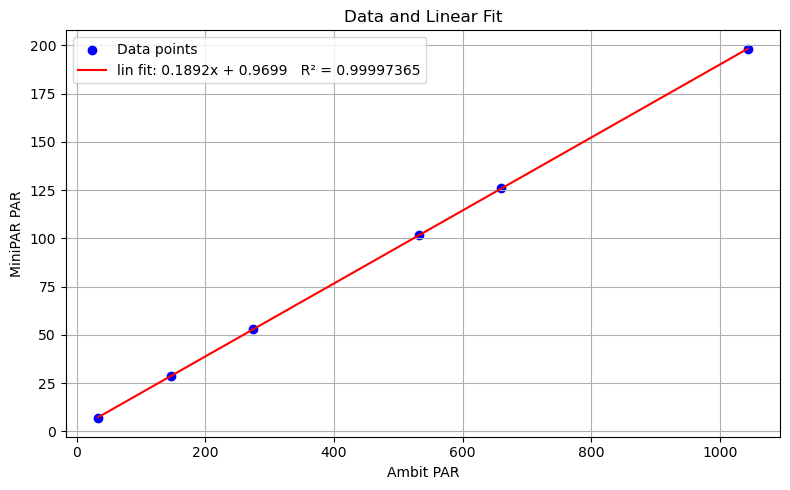

Old ambit PAR coefficient: 0.0693


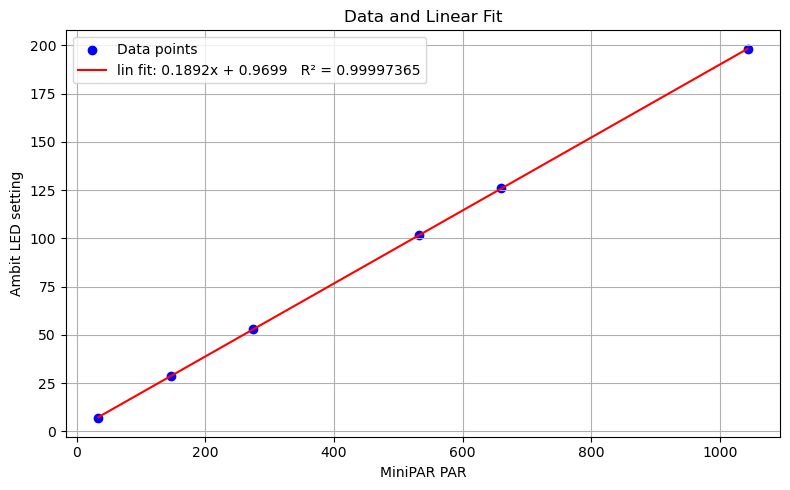

In [ ]:
# callibration of the light sensor in the Ambit

currents = [0.2, 0.4, 0.8, 1.0, 1.6, 0]
reference_data = []
sensor_data = []
for I in currents:
    set_current(port=PORT_DC_SOURCE, current=I)
    time.sleep(1.0)
    ref_val = get_par_MP(PORT_MINIPAR_PAR)
    sens_val = get_par_AMB(PORT_AMBIT, raw=True)
    reference_data.append(ref_val)
    sensor_data.append(sens_val)

# Analysis functions
# (r_squared and plot_data_and_fit are now imported from helpers.py)

y = reference_data
x = sensor_data
coeffs = np.polyfit(x, y, 1)
y_pred = np.polyval(coeffs, x)
r2 = r_squared(y, y_pred)


# info about the fit
info = ambit_reboot(PORT_AMBIT)
print("Old ambit PAR coefficient:", info.act_led_coeff)
plot_data_and_fit(x, y, coeffs, r2, xlabel="Ambit PAR", ylabel="MiniPAR PAR")
 

In [8]:
# Upload PAR calibration coefficients to the Ambit
# This section demonstrates how to use set_par_gain
from helpers import set_par_gain, ambit_reboot, AmbitInfo

# Example:
slope = coeffs[0]
#offset = coeffs[1]
info = ambit_reboot(PORT_AMBIT)
old_slope =info.light_slope
print(f"Uploading PAR gain: {slope:.4f}")
set_par_gain(PORT_AMBIT, slope)
info = ambit_reboot(PORT_AMBIT)

print(f"Old PAR gain: {old_slope:.4f}, New PAR gain: {info.light_slope:.4f}") 

Uploading PAR gain: 0.1892
Old PAR gain: 0.1667, New PAR gain: 0.1892


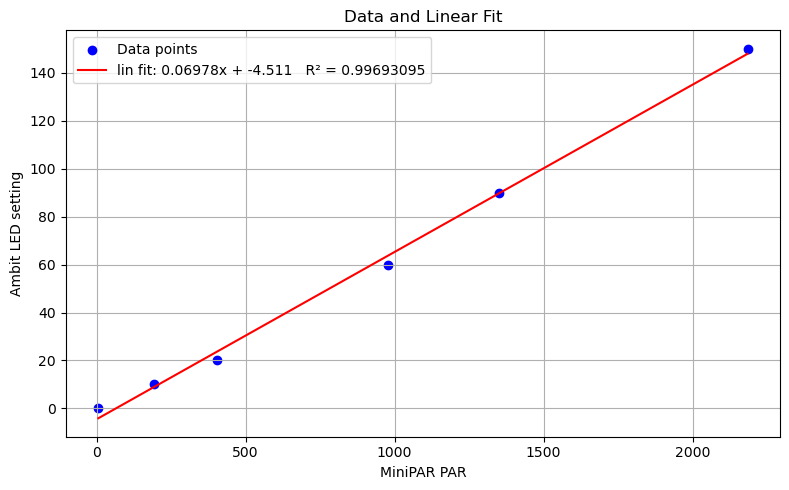

In [9]:
# Callibration of the light emmission of the Ambit LED
#ambit_reboot(PORT_AMBIT)
currents = [  10, 20, 60, 90, 150, 0]
reference_data = []
sensor_data = []
for I in currents:
    set_ambit_led(PORT_AMBIT, I)
    time.sleep(0.2)
    sens_val = get_par_MP(PORT_MINIPAR_EMIT)
    reference_data.append(I)
    sensor_data.append(sens_val)
   
# inspection plot for LED callibration
y = reference_data
x = sensor_data
coeffs = np.polyfit(x, y, 1)
y_pred = np.polyval(coeffs, x)
r2 = r_squared(y, y_pred)

plot_data_and_fit(x,y, coeffs, r2, ylabel="Ambit LED setting", xlabel="MiniPAR PAR")

In [10]:
# Upload LED gain calibration to the Ambit
light_gain = coeffs[0]
info = ambit_reboot(PORT_AMBIT)
old_slope = info.act_led_coeff
set_ambit_led_gain(PORT_AMBIT, light_gain)
info = ambit_reboot(PORT_AMBIT)
print(f"Old LED gain: {old_slope:.4f}, New LED gain: {info.act_led_coeff:.4f}")

Old LED gain: 0.0693, New LED gain: 0.0698


In [12]:
print(info)

FW: b'0.0.3', light_slope: 0.1892, IsValid: True, name: b'AmbitV002', actinic gain: 0.0698


In [18]:
# optional check of the sensor health
# PAR sensor cross-check

set_current(port=PORT_DC_SOURCE, current=1.2)
time.sleep(1.0)
s1 = get_par_MP(PORT_MINIPAR_PAR)
s2 = get_par_MP(PORT_MINIPAR_EMIT)

print(f"PAR reading from PAR sensor: {s1:.4f}")
print(f"PAR reading from LED sensor: {s2:.4f}")
set_current(port=PORT_DC_SOURCE, current=0.0)

PAR reading from PAR sensor: 156.3500
PAR reading from LED sensor: 156.8800


In [ ]:
# Continuous monitoring of the PAR sensor (press Ctrl+C to stop)
set_current(port=PORT_DC_SOURCE, current=1.0)
time.sleep(1.0)
try:
    while True:
        s1 = get_par_MP(PORT_MINIPAR_PAR)
        print(f"PAR reading from PAR sensor: {s1:.4f}")
        time.sleep(1.0)
except KeyboardInterrupt:
    pass

set_current(port=PORT_DC_SOURCE, current=0.0)

PAR reading from PAR sensor: 467.9000
PAR reading from PAR sensor: 466.6400
PAR reading from PAR sensor: 465.7400
PAR reading from PAR sensor: 466.1700
PAR reading from PAR sensor: 464.7500
PAR reading from PAR sensor: 464.5100
PAR reading from PAR sensor: 463.8500
PAR reading from PAR sensor: 464.2000
PAR reading from PAR sensor: 470.5700
